--- 
---
# TP6 – SVM
---

**Nom : DIALLO**  
**Prénom : Mamadou djouldé**  
**Cursus : M1 SysCom**


--- 

## Objectif du TP : 

Ce TP vise à implémenter et comprendre les Machines à Vecteurs de Support (SVM).
On débutera par la visualisation de données et la résolution manuelle du SVM linéaire (marge dure) via le problème primal.
Ensuite, on explorera le concept de marge souple pour gérer les données non séparables, en analysant l'impact du paramètre C.
Enfin, vous appliquerez différents noyaux (RBF, polynomial) pour apprendre des frontières de décision non linéaires.

---
---

--- 
---
## I. Plan Séparateur


Import des libs nécessaires : 

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import cvxopt
from cvxopt import matrix
from sklearn import svm

- Code base du TP6 : 

In [21]:

def aff_donnees(X,y,bornex,borney,s):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=s, cmap='winter')

    plt.xlim(bornex)
    plt.ylim(borney)

def aff_frontiere(X,y,bornex,borney,model):
    aff_donnees(X,y,bornex,borney,50)
    xx, yy = np.meshgrid(np.linspace(bornex[0], bornex[1],100), np.linspace(borney[0], borney[1],100))
    xy = np.concatenate((np.reshape(xx,(xx.shape[0]*xx.shape[1],1)),np.reshape(yy,(yy.shape[0]*yy.shape[1],1))),axis=1)
    P = model.predict(xy)
    aff_donnees(xy,P,bornex,borney,1) 

### Affichage des données en mettant un symbole différent pour les exemples positifs et negatifs.

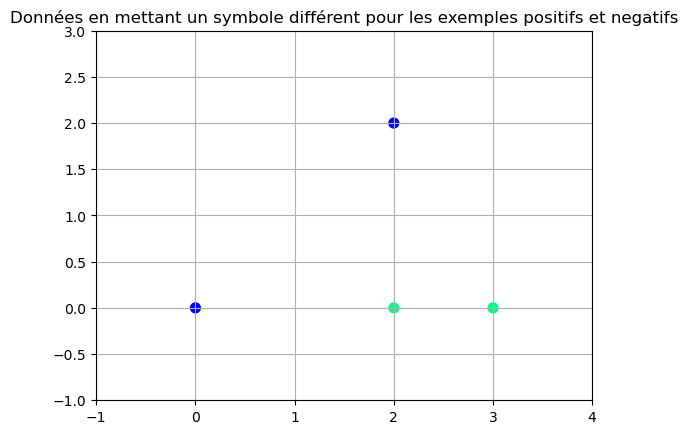

In [22]:
# Données de l'exemple du cours
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0]])
y = np.array([-1, -1, 1, 1])

# Définition des bornes
bornex = [np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1]
borney = [np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1]

# Taille des symboles
s = 50

# Affichage des données
aff_donnees(X, y, bornex, borney, s)
plt.title("Données en mettant un symbole différent pour les exemples positifs et negatifs")
plt.grid(True)
plt.show()

### Fonction **affichePlan(𝐰,𝑏,𝑏𝑜𝑟𝑛𝑒𝑥)** qui affiche un hyperplan dans le plan 2D

Pour faire le code on va partir de l'equation d'un hyperplan générale :
$$w^T x + b = 0$$

En dimension 2, $w = \begin{pmatrix} w_1 \\ w_2 \end{pmatrix}$ et $x = \begin{pmatrix} x_1 \\ x_2 \end{pmatrix}$.

L'équation devient :
$$[w_1, w_2] \cdot \begin{pmatrix} x_1 \\ x_2 \end{pmatrix} + b = 0$$
$$w_1 x_1 + w_2 x_2 + b = 0$$

Pour l'affichage (avec $x_1$ en abscisse et $x_2$ en ordonnée), on isole $x_2$ :
$$w_2 x_2 = - (w_1 x_1 + b)$$
$$x_2 = - \frac{w_1 x_1 + b}{w_2}$$

In [23]:
def affichePlan(w, b, bornex):
    
    # w[0] c'est w1, w[1] c'est w2
    
    # On crée 2 points pour l'axe x (x1) debut et fin
    x1_points = np.array([bornex[0], bornex[1]])

    # vu qu'on a une fraction on va eviter la division par 0 si w2 est nul.
    if w[1] != 0:
        x2_points = (-w[0] * x1_points - b) / w[1]
        plt.plot(x1_points, x2_points, 'r-', label='Hyperplan')
        
    # Si w2 est nul
    elif w[0] != 0 :
        # L'équation est w1*x1 + b = 0  =>  x1 = -b / w1
        x1_points = -b / w[0]
        
        # On récupère les limites y (ymin, ymax) du graphe
        ymin, ymax = plt.ylim() 
        
        # On trace la ligne verticale
        plt.plot([x1_points, x1_points], [ymin, ymax], 'r-', label='Hyperplan')
        plt.ylim(ymin, ymax)

    else :
        print("w1 et w2 sont tous les deux nuls")

- Affichage de l'hyperplan pour W = [1,0.1] et b = -1

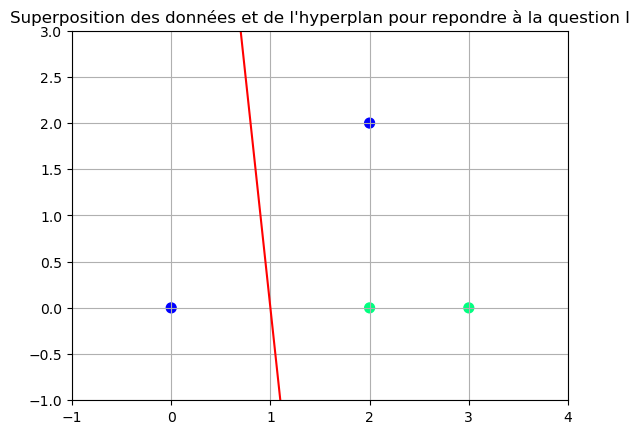

In [24]:
w = [1,0.1]
b = -1 

aff_donnees(X, y, bornex, borney, s)
Affichage = affichePlan(w,b,bornex)
plt.title("Superposition des données et de l'hyperplan pour repondre à la question I")
plt.grid(True)
plt.show()

---
### Reponse I : 

Non, ce n'est pas un hyperplan separateur.

Pour l'etre, tous les points bleus (classe +1) devraient être du même côté de la droite, et tous les points verts (classe -1) de l'autre côté.

Ici, on voit que la droite sépare les deux points bleus (0,0) et (2,2) l'un de l'autre. Le point (0,0) est d'un côté et le point (2,2) est de l'autre. Comme la droite passe "au milieu" d'une même classe, elle ne peut pas séparer les deux classes.

---

---
---

---
--- 

## II SVM Linéaire dans le primal 



On  a  vu  en  cours  que  le  problème  des  SVM  peut  être  mis  sous  la  forme  d’un  problème 
quadratique  dont  la  solution  est  obtenue  avec  la  librairie  cvxopt.  

- Complétons  la  fonction ResoudPrimal(X,y) qui renvoie les paramètres 𝒘 et 𝑏 de l’hyperplan séparateur. 

On transforme cela en problème quadratique standard :
$$\min \frac{1}{2} z^T P z + q^T z \quad \text{sc} \quad Gz \le h$$

Où 
$$z = \begin{pmatrix} b \\ w \end{pmatrix}$$

**$1^{\text{ère}} \text{ étape : Construction de la matrice P :}$**
$$P = \begin{bmatrix} 0 & \mathbf{0}_{1,d} \\ \mathbf{0}_{d,1} & I_d \end{bmatrix}$$

**$2^{\text{ème}} \text{ étape : Construction de la matrice q :}$**
Pas de terme linéaire, donc $q = 0_{d+1}$

**$3^{\text{ème}} \text{ étape : Construction des sc d'inégalité } Gz \le h$**
*La contrainte $-y_i(w^T x_i + b) \le -1$ se réécrit $-y_i b - (y_i x_i^T) w \le -1$ (pour suivre l'ordre $z = [b, w]^T$).*

$$h = \begin{pmatrix} -1 \\ \vdots \\ -1 \end{pmatrix} \quad ; \quad G = \begin{bmatrix} -y_1 & -y_1 x_1^T \\ \vdots & \vdots \\ -y_N & -y_N x_N^T \end{bmatrix}$$

In [25]:
def ResoudPrimal(X, y) :
    
    # Récupération des dimensions
    n, d = X.shape  # n = nombre d'exemples, d = nombre de dimensions
    
    # 1ère étape :
    P = np.zeros((d + 1, d + 1))
    for i in range(d):
        P[i+1, i+1] = 1.0  
    P = cvxopt.matrix(P)  # Conversion en matrice cvxopt

    # 2ème étape :
    q = np.zeros(d + 1)
    q = cvxopt.matrix(q)  # Conversion en matrice cvxopt

    # 3ème étape :
    G = np.zeros((n, d + 1))
    h = np.zeros(n)
    
    for i in range(n):
        G[i, 0] = -y[i]
        for j in range(d):
            G[i, j+1] = -y[i] * X[i, j]
        # h est toujours -1
        h[i] = -1.0
        
    # Conversion en matrices cvxopt
    G = cvxopt.matrix(G)
    h = cvxopt.matrix(h)

    # solution
    sol = cvxopt.solvers.qp(P, q, G, h)

    #  z = [b, w])
    z = sol['x']
    z = np.array(z).flatten()  # Conversion en array
    
    # b est la première composante
    b = z[0]
    # w est tout le reste
    w = z[1:]
    
    return w, b

- Verifions le programme en traçant l'hyperplan 

     pcost       dcost       gap    pres   dres
 0:  3.2653e-01  1.9592e+00  6e+00  2e+00  4e+00
 1:  1.5796e+00  8.5663e-01  7e-01  2e-16  2e-15
 2:  1.0195e+00  9.9227e-01  3e-02  2e-16  6e-16
 3:  1.0002e+00  9.9992e-01  3e-04  1e-16  2e-15
 4:  1.0000e+00  1.0000e+00  3e-06  2e-16  2e-15
 5:  1.0000e+00  1.0000e+00  3e-08  0e+00  1e-15
Optimal solution found.
w = [ 1.00000001 -1.00000001]
b = -1.0000000134075104


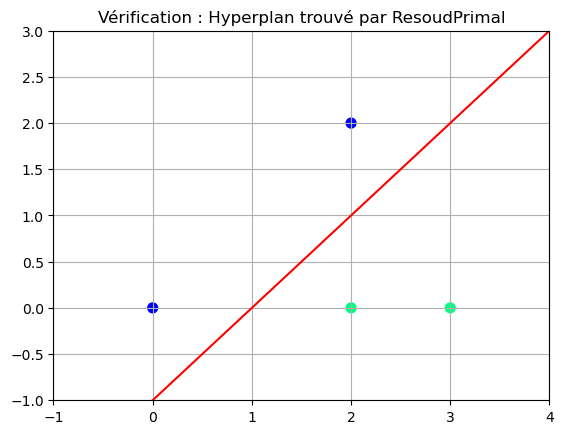

In [26]:
w_primal, b_primal = ResoudPrimal(X, y) # Appel de la fonction resoudprimal
print(f"w = {w_primal}")
print(f"b = {b_primal}")

# On trace le graphe en utilisant les fonctions aff qu'on a definit precedement

aff_donnees(X, y, bornex, borney, s=50)
# On trace l'hyperplan trouvé par ResoudPrimal
affichePlan(w_primal, b_primal, bornex)
plt.title("Vérification : Hyperplan trouvé par ResoudPrimal")
plt.grid(True)
plt.show()

---
### Reponses II : 

- L'hyperplan (la ligne rouge) est bien correct. 
    - On voit qu'il sépare bien les deux classes, tous les points bleus (classe -1) sont d'un côté et tous les points verts (classe +1) sont de l'autre.

    - En plus, il a l'air optimal car il semble passer pile à "mi-chemin" entre les points les plus proches des deux classes (le point (2,2) et le point (2,0)), ce qui maximise la marge entre les classes.

- Verifions en faisant tourner le programme si on ajoute le point X = [2.1,2.5] d'etiquette 1.

     pcost       dcost       gap    pres   dres
 0:  1.8212e-01  5.5124e+00  1e+01  2e+00  5e+00
 1:  5.5352e-01  1.0158e+01  5e+00  1e+00  3e+00
 2:  1.0266e+00  4.3072e+01  7e+00  1e+00  3e+00
 3:  9.6056e+00  1.2385e+02  2e+01  1e+00  2e+00
 4:  5.1885e+02  2.6193e+02  3e+02  8e-15  1e-10
 5:  3.2241e+02  3.1119e+02  1e+01  5e-15  1e-10
 6:  3.1309e+02  3.1298e+02  1e-01  4e-15  2e-11
 7:  3.1300e+02  3.1300e+02  1e-03  7e-15  3e-11
 8:  3.1300e+02  3.1300e+02  1e-05  4e-15  8e-11
Optimal solution found.
w = [25.00000037 -1.00000002]
b = -49.00000074364595


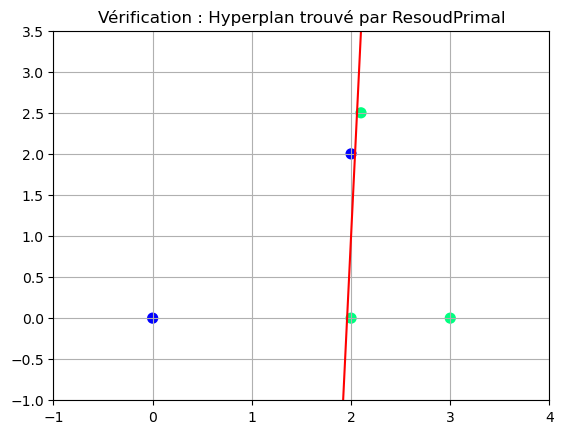

In [27]:
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0], [2.1, 2.5]])
y = np.array([-1, -1, 1, 1, 1])

# Définition des bornes
bornex = [np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1]
borney = [np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1]
# Taille des symboles
s = 50

w_primal, b_primal = ResoudPrimal(X, y) # Appel de la fonction resoudprimal
print(f"w = {w_primal}")
print(f"b = {b_primal}")

# On trace le graphe en utilisant les fonctions aff qu'on a definit precedement

aff_donnees(X, y, bornex, borney, s)
# On trace l'hyperplan trouvé par ResoudPrimal
affichePlan(w_primal, b_primal, bornex)
plt.title("Vérification : Hyperplan trouvé par ResoudPrimal")
plt.grid(True)
plt.show()

On observe bien que le point [2.1, 2.5] est bien classé +1 (en couleur verte) et l'hyperplan arrive à peine à séparer les deux classes. Disons qu'on est sur la limite, avec une marge quasi nulle. Si le point [2.1, 2.5] était plus à gauche, le SVM linéaire n'aurait sûrement pas marché.

- Cas pour X = [1.5,2.5] : 

     pcost       dcost       gap    pres   dres
 0:  1.1899e-01  3.3014e+00  5e+00  2e+00  7e-16
 1:  2.2134e-02  7.3948e+00  6e-01  1e+00  2e-15
 2:  1.0266e-03  4.5487e+01  2e+00  1e+00  3e-14
 3:  5.9225e-06  8.5972e+02  5e+00  1e+00  2e-13
 4:  4.1485e-10  1.4069e+05  9e+00  1e+00  1e-10
 5:  4.1364e-14  2.1511e+09  1e+03  1e+00  2e-07
 6:  4.1364e-18  3.2872e+15  2e+07  1e+00  0e+00
 7:  4.1369e-22  5.0234e+23  3e+13  1e+00  7e+07
 8:  1.6967e-22  6.8914e+33  5e+22  1e+00  5e+17
 9:  1.4508e-22  1.5615e+44  9e+32  1e+00  4e+28
10:  1.1198e-22  3.1662e+54  2e+43  1e+00  5e+38
11:  1.1076e-22  3.0921e+63  2e+52  1e+00  3e+47
12:  8.6734e-23  6.7617e+73  3e+62  1e+00  1e+58
13:  8.6706e-23  3.1901e+81  1e+70  1e+00  1e+66
14:  8.2612e-24  5.5853e+92  5e+80  1e+00  5e+76
15:  8.4261e-24  7.3988e+100  6e+88  1e+00  2e+85
16:  7.6793e-24  1.0759e+109  9e+96  1e+00  5e+92
17:  7.7088e-24  5.6810e+116  5e+104  1e+00 7e+100
18:  9.3129e-24  1.6431e+122  1e+110  1e+00 1e+109
19:  2.9609e-24

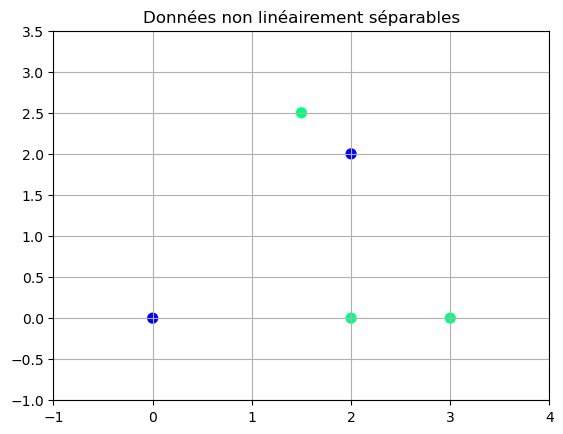

In [28]:
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0], [1.5, 2.5]])
y = np.array([-1, -1, 1, 1, 1])

# Définition des bornes
bornex = [np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1]
borney = [np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1]
# Taille des symboles
s = 50

try:  # Pour ne pas que le progamme plante
	w_primal, b_primal = ResoudPrimal(X, y) # Appel de la fonction resoudprimal
	print(f"w = {w_primal}")
	print(f"b = {b_primal}")

	# On trace le graphe en utilisant les fonctions aff qu'on a definit precedement
	aff_donnees(X, y, bornex, borney, s)
	# On trace l'hyperplan trouvé par ResoudPrimal
	affichePlan(w_primal, b_primal, bornex)
	plt.title("Vérification : Hyperplan trouvé par ResoudPrimal")
	plt.grid(True)
	plt.show()
	
except Exception as e:
	print(f"Erreur: {e}")
	print("Les données ne sont pas linéairement séparables.")
	print("Le SVM linéaire dans le primal ne peut pas trouver de solution.")
	
	# Affichage des données sans hyperplan
	aff_donnees(X, y, bornex, borney, s)
	plt.title("Données non linéairement séparables")
	plt.grid(True)
	plt.show()

Quand on ajoute le point [1.5, 2.5], le programme ResoudPrimal plante et renvoie une ValueError. Ce nouveau point (vert) se trouve "derrière" le point bleu (2, 2), ce qui rend les données non linéairement séparables. Le SVM linéaire dans le primal ne peut pas trouver de solution parfaite qui sépare tout, donc le solveur cvxopt échoue.

---

---
---


---
---
## III SVM à marge souple :

On va utiliser l’apprentissage SVM de python qui autorise les marges souples.

In [29]:
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0]])
y = np.array([-1, -1, 1, 1])

s = 50
C_test = 1000.0 # Valeur de test pour C

model = svm.SVC(kernel='linear', C = C_test)
model.fit(X, y)
w_souple = model.coef_[0]
b_souple = model.intercept_[0]

### Affichons  l’hyperplan  obtenu  avec  la  fonction  aff_plan()  précédente  puis  avec  la  fonction aff_frontiere() donnée en annexe. 

w = [ 1. -1.]
b = -1.0


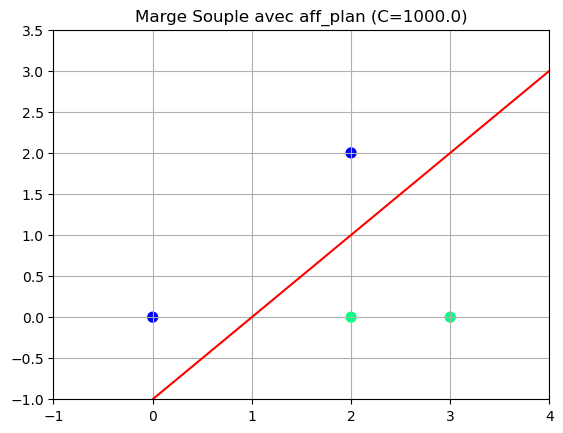

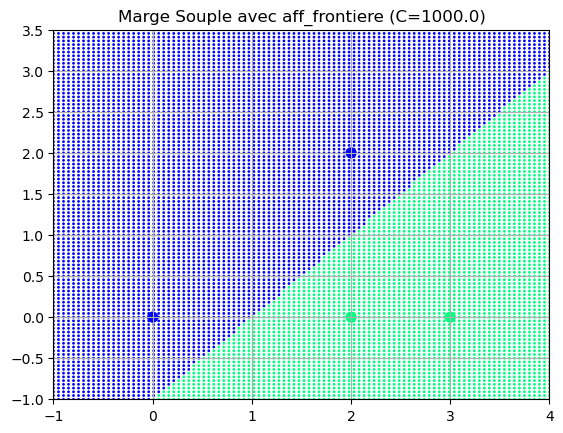

In [30]:
# Utilisation des paramètres du modèle SVM à marge souple déjà calculé
print(f"w = {w_souple}")
print(f"b = {b_souple}")

# Affichage avec aff_plan
aff_donnees(X, y, bornex, borney, s)
affichePlan(w_souple, b_souple, bornex)
plt.title(f"Marge Souple avec aff_plan (C={C_test})")
plt.grid(True)
plt.show()

# Affichage avec aff_frontiere
aff_frontiere(X, y, bornex, borney, model) 
plt.title(f"Marge Souple avec aff_frontiere (C={C_test})")
plt.grid(True)
plt.show()

---

### Reponses III : 

- Comme vu en cours, la variable C represente le parametre de pénalité du SVM, plus C est grand plus on pénalise les erreurs en forçant le SVM à être tres strict et de tout bien classer. Tandisque si C est pétit on priorise la marge et on n'est pas strict dans le sens de bien tout classer, tout ce qui nous interresse c'est d'avoir une grande marge. 

- Ajoutons le point X = [2.1, 2.5] :

w pour C = 1.0 = [ 0.99996562 -0.03999866]
b pour C = 1.0 = -0.9999540665513229


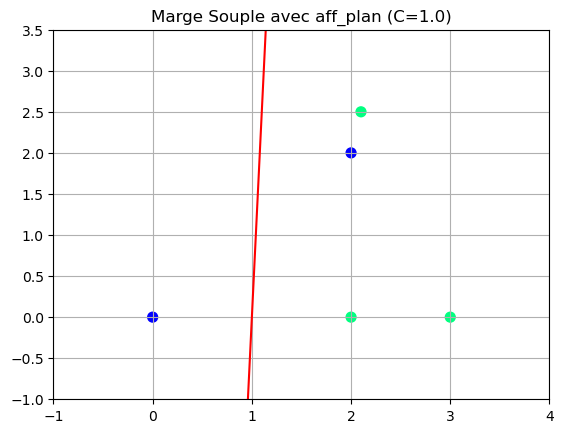

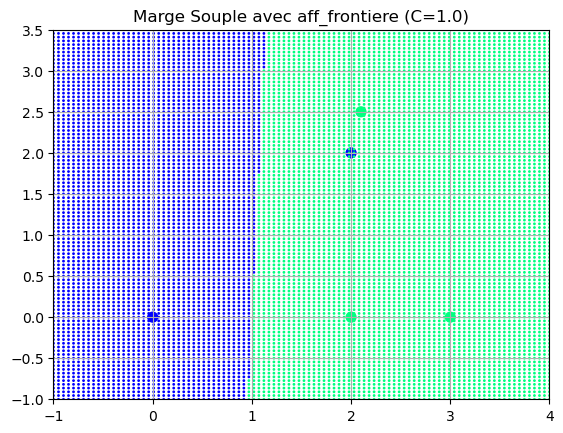

w pour C = 1000.0 = [24.98702955 -0.99950406]
b pour C = 1000.0 = -48.974342065517


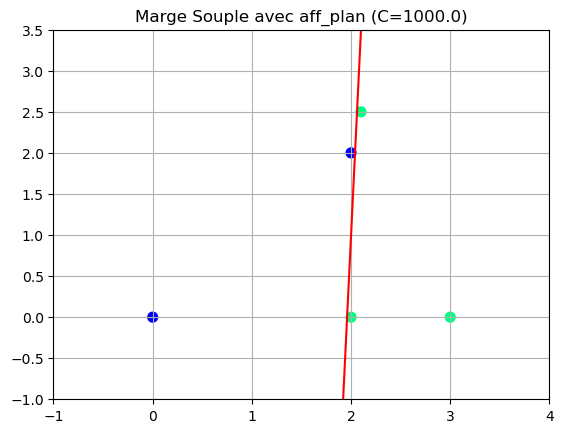

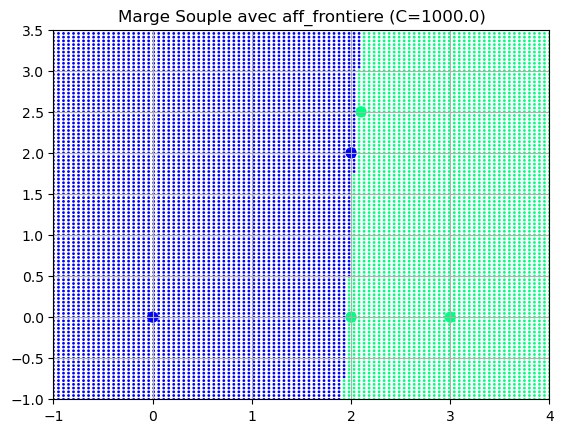

In [31]:
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0], [2.1, 2.5]])
y = np.array([-1, -1, 1, 1, 1])

s = 50
C_tests = [1.0,1000.0] # Valeur de test pour C

for C_test in C_tests : 

    model = svm.SVC(kernel='linear', C = C_test)
    model.fit(X, y)
    w_souple = model.coef_[0]
    b_souple = model.intercept_[0]

    # Utilisation des paramètres du modèle SVM à marge souple déjà calculé
    print(f"w pour C = {C_test} = {w_souple}")
    print(f"b pour C = {C_test} = {b_souple}")

    # Affichage avec aff_plan
    aff_donnees(X, y, bornex, borney, s)
    affichePlan(w_souple, b_souple, bornex)
    plt.title(f"Marge Souple avec aff_plan (C={C_test})")
    plt.grid(True)
    plt.show()

    # Affichage avec aff_frontiere
    aff_frontiere(X, y, bornex, borney, model) 
    plt.title(f"Marge Souple avec aff_frontiere (C={C_test})")
    plt.grid(True)
    plt.show()

En observant pour deux valeurs de C (C=1.0 et C=1000.0), on voit bien la différence de pénalité.

Pour C = 1.0, on a une priorité pour obtenir une grnde marge, et ceci même s'il y'a des points qui sont mal classés (on voit bien sur le graphe aff_frontiere que le point bleu (2, 2) est dans la zone verte).

Pour une valeur de C plus grande (ici 1000), on est strict pour éviter les erreurs. C'est comme la partie II du TP : on est en mode SVM primal où on est obligé de séparer les classes, au détriment s'il faut de la marge (qui devient quasi nulle).

- Ajoutons le point X = [1.5, 2.5] :

w pour C = 1.0 = [0.99983433 0.19996687]
b pour C = 1.0 = -0.999779110551822


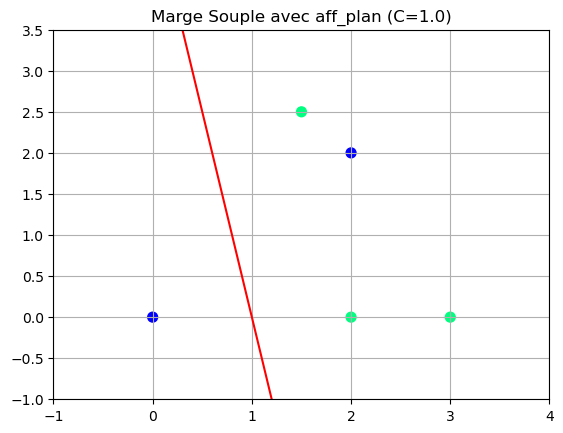

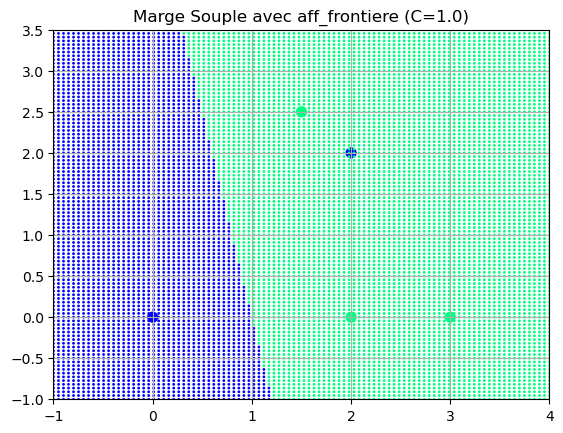

w pour C = 1000.0 = [1.         0.19966907]
b pour C = 1000.0 = -0.9997242236718021


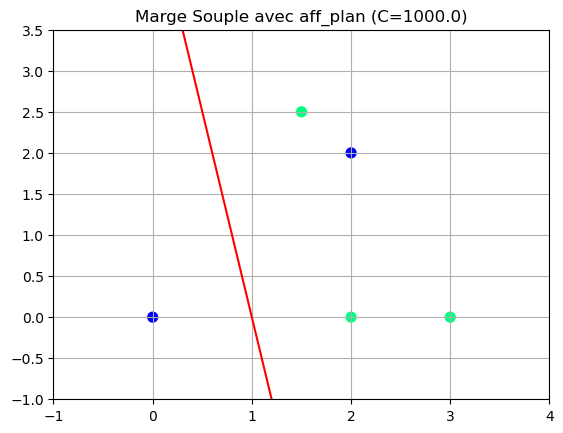

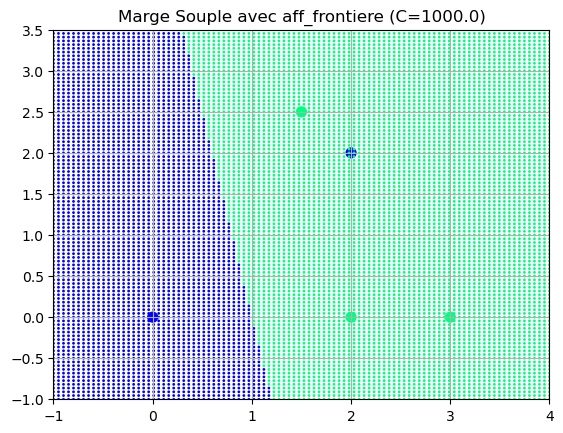

In [32]:
X = np.array([[0, 0], [2, 2], [2, 0], [3, 0], [1.5, 2.5]])
y = np.array([-1, -1, 1, 1, 1])

s = 50
C_tests = [1.0,1000.0] # Valeur de test pour C

for C_test in C_tests : 

    model = svm.SVC(kernel='linear', C = C_test)
    model.fit(X, y)
    w_souple = model.coef_[0]
    b_souple = model.intercept_[0]

    # Utilisation des paramètres du modèle SVM à marge souple déjà calculé
    print(f"w pour C = {C_test} = {w_souple}")
    print(f"b pour C = {C_test} = {b_souple}")

    # Affichage avec aff_plan
    aff_donnees(X, y, bornex, borney, s)
    affichePlan(w_souple, b_souple, bornex)
    plt.title(f"Marge Souple avec aff_plan (C={C_test})")
    plt.grid(True)
    plt.show()

    # Affichage avec aff_frontiere
    aff_frontiere(X, y, bornex, borney, model) 
    plt.title(f"Marge Souple avec aff_frontiere (C={C_test})")
    plt.grid(True)
    plt.show()

Pour le point x = [1.5, 2.5], on a vu à la dernière question de la partie II qu'il est impossible de séparer les classes lineairement.

Et donc pour notre cas ici, on voit que le SVM (à marge souple) trouve exactement la meme chose pour les deux valeurs de C (on obtient la meme droite).

Non seulement on ne peut pas faire une separation lineaire, mais meme la valeur C = 1000 (qui demande d'être strict pour éviter les erreurs) ne marche pas comme on pourrait le penser, elle est obligée d'accepter une ereur et se comporte donc comme le C = 1.0. Dans les deux cas, le SVM a sacrifié le point (2, 2) (le point bleu, qui se retrouve en zone verte) pour trouver la meilleure solution possible.

---

---
---

---
---
## IV SVM avec Kernel : 

Dans cette partie, on travaillera sur les données <<TP6.npz>>

In [33]:
f = np.load('TP6.npz',allow_pickle=True) 
X=f['arr_0'] 
y=f['arr_1'] 

### Apprenons directement un SVM avec un kernel linéaire et affichons la fonction de décision avec **aff_frontiere(X,y,bornex,borney,model) (display)**.

c:\Users\mamad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


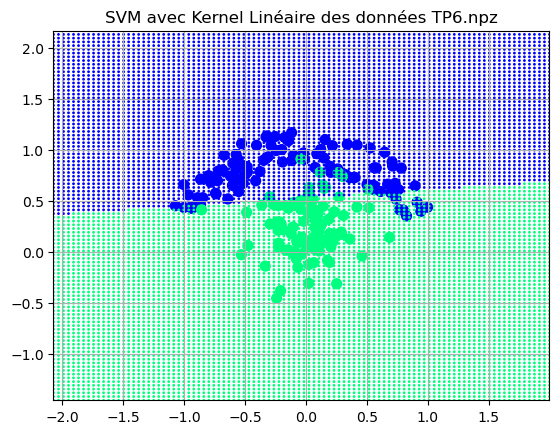

In [34]:
#Redéfinir les bornes pour ces NOUVELLES données X
bornex_nouvelle = [np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1]
borney_nouvelle = [np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1]

# Apprendre un SVM avec un kernel linéaire
model_lineaire = svm.SVC(kernel='linear', C=1.0)
# Entraîner le modèle
model_lineaire.fit(X, y)

# Affichage de la fonction de décision
aff_frontiere(X, y, bornex_nouvelle, borney_nouvelle, model_lineaire)
plt.title("SVM avec Kernel Linéaire des données TP6.npz")
plt.grid(True)
plt.show()

### Apprenons les SVM avec des noyaux linéaire, rbf et polynomial.

c:\Users\mamad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


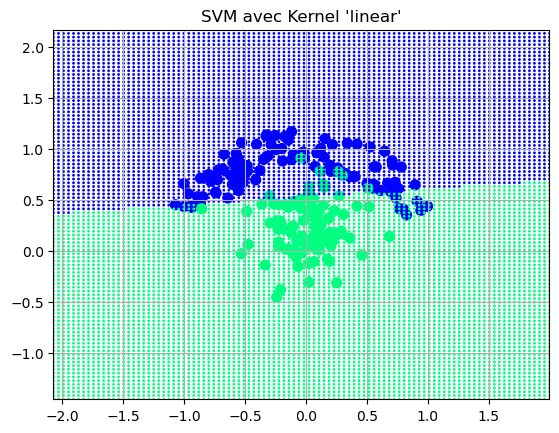

c:\Users\mamad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


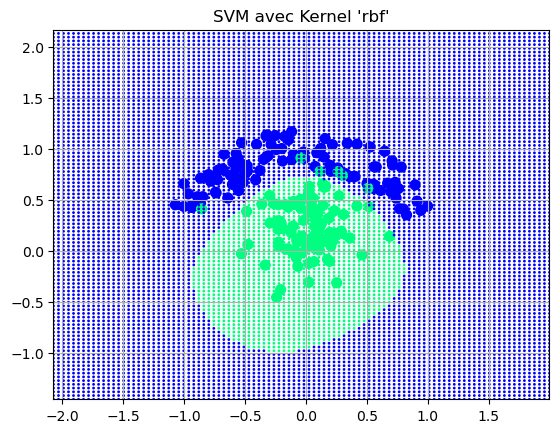

c:\Users\mamad\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


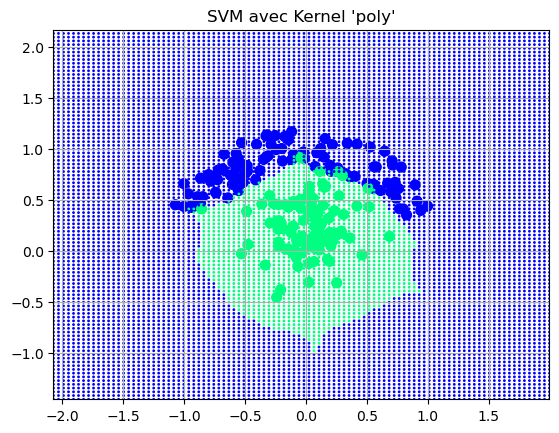

In [35]:
# Liste des kernels à tester
kernel_list = ['linear', 'rbf', 'poly']

#  Boucle sur les kernels
for kernel_name in kernel_list:
    model = svm.SVC(kernel=kernel_name, C=1., degree=20)
    model.fit(X, y)
    
    # Afficher la fonction de décision
    aff_frontiere(X, y, bornex_nouvelle, borney_nouvelle, model)
    plt.title(f"SVM avec Kernel '{kernel_name}'")
    plt.grid(True)
    plt.show()

#### Remarque sur les nouvelles fonctions de decision : 

En observant les trois graphiques obtenus avec les différents kernels, on remarque :

**Kernel Linéaire** : La frontière de décision est une droite. On voit que cette droite n'arrive pas parfaitement à séparer les deux classes car les données ne sont pas linéairement séparables.

**Kernel RBF** : La frontiere de decision devient non lineaire. Le kernel RBF arrive à mieux entourer les groupes de points de chaque classe, créant des zones de décision plus adaptées.

**Kernel Polynomial** : Comme le kernel RBF, il crée une frontière non linéaire, mais avec des formes différentes. Les frontières sont moins arrondies que le RBF.

---
### Reponses IV : 

- Non, on ne peut pas apprendre des frontières non linéaires avec un noyau linéaire. Si on ne peut pas separer les données linéairement, il faut absolument utiliser des kernels non linéaires comme RBF ou polynomial d'apres ce qu'on observe car ils sont plus adapter que le kernel linéaire.

- Testons le svm avec rbf avec les données de départ :

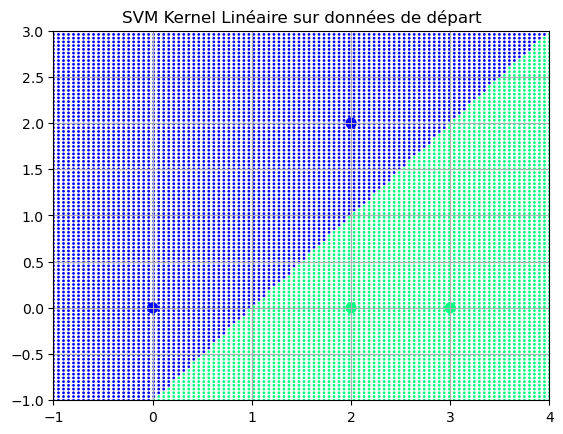

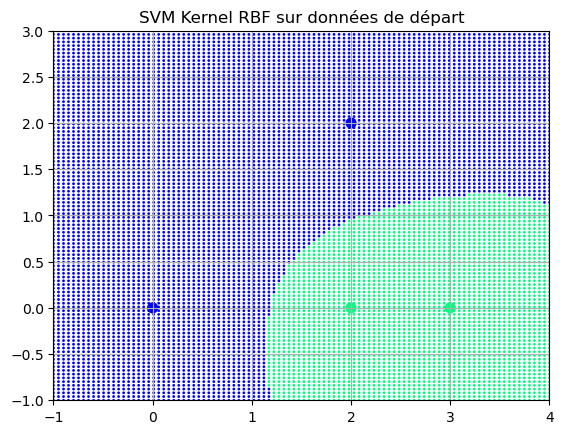

In [36]:
# Test du kernel RBF sur les données de départ (linéairement séparables)
X_debut = np.array([[0, 0], [2, 2], [2, 0], [3, 0]])
y_debut = np.array([-1, -1, 1, 1])

# Bornes pour ces données
bornex = [np.min(X_debut[:, 0]) - 1, np.max(X_debut[:, 0]) + 1]
borney= [np.min(X_debut[:, 1]) - 1, np.max(X_debut[:, 1]) + 1]

# Test avec kernel RBF
model_rbf = svm.SVC(kernel='rbf', C=1.0)
model_rbf.fit(X_debut, y_debut)

# Test avec kernel linéaire pour comparaison
model_linear_debut = svm.SVC(kernel='linear', C=1.0)
model_linear_debut.fit(X_debut, y_debut)

# Affichage kernel linéaire
aff_frontiere(X_debut, y_debut, bornex, borney, model_linear_debut)
plt.title("SVM Kernel Linéaire sur données de départ")
plt.grid(True)
plt.show()

# Affichage kernel RBF
aff_frontiere(X_debut, y_debut, bornex, borney, model_rbf)
plt.title("SVM Kernel RBF sur données de départ")
plt.grid(True)
plt.show()

Le SVM avec kernel RBF fonctionne sur les données linéairement séparables mais il n'est pas forcément le mieux adapté. 

Pour des données linéairement séparables, le kernel linéaire reste le plus approprié car il donne une solution plus simple, plus rapide et plus générale. Le kernel RBF peut marcher mais c'est comme utiliser un marteau-pilon pour enfoncer une punaise.

---

---
---

---
---

## Conclusion Générale : 

Ce TP m'a permis de bien comprendre le fonctionnement des SVM.

D'abord, j'ai vu comment résoudre le problème primal pour des données linéairement séparables, en transformant le problème d'optimisation en problème quadratique avec cvxopt.

Ensuite, j'ai expérimenté l'utilité de la marge souple avec le paramètre C pour gérer les données non séparables. Plus C est grand, plus on pénalise les erreurs, et plus C est petit, plus on privilégie une grande marge.

Enfin, l'exploration des différents kernels (linéaire, RBF, polynomial) m'a montré comment passer de frontières linéaires à des frontières complexes pour traiter des données non linéairement séparables.

Le choix du bon kernel dépend vraiment des données : kernel linéaire pour des données séparables lineairement, et kernels non linéaires (RBF, poly) pour des données plus complexes.

---
---